<a href="https://colab.research.google.com/github/Dhlih/Eksperimen_SML_Ifad/blob/main/Eksperimen_Ifad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

   **Sumber dataset saya:**
   Dataset yang saya gunakan, yaitu MyAnimeList Anime and Manga Datasets yang bersumber dari Kaggle. Dataset ini berisi informasi-informasi yang berkaitan dengan anime, seperti judul, studio, episode, sinopsis, dll.

   Target Variabel: score
   
   Fitur Utama: synopsis, licensors, studios, episodes, type, duration, source, genres, producers, status

   Link Dataset: https://www.kaggle.com/datasets/andreuvallhernndez/myanimelist


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [177]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [178]:
df = pd.read_csv("anime.csv")
df.head()

,anime_id,title,type,score,scored_by,status,episodes,start_date,end_date,source,...,producers,licensors,synopsis,background,main_picture,url,trailer_url,title_english,title_japanese,title_synonyms
0,5114,Fullmetal Alchemist: Brotherhood,tv,9.10,2037075,finished_airing,64.0,2009-04-05,2010-07-04,manga,...,"['Aniplex', 'Square Enix', 'Mainichi Broadcast...","['Funimation', 'Aniplex of America']",After a horrific alchemy experiment goes wrong...,NaN,https://cdn.myanimelist.net/images/anime/1208/...,https://myanimelist.net/anime/5114/Fullmetal_A...,https://www.youtube.com/watch?v=--IcmZkvL0Q,Fullmetal Alchemist: Brotherhood,鋼の錬金術師 FULLMETAL ALCHEMIST,['Hagane no Renkinjutsushi: Fullmetal Alchemis...
1,11061,Hunter x Hunter (2011),tv,9.04,1671587,finished_airing,148.0,2011-10-02,2014-09-24,manga,...,"['VAP', 'Nippon Television Network', 'Shueisha']",['VIZ Media'],Hunters devote themselves to accomplishing haz...,NaN,https://cdn.myanimelist.net/images/anime/1337/...,https://myanimelist.net/anime/11061/Hunter_x_H...,https://www.youtube.com/watch?v=D9iTQRB4XRk,Hunter x Hunter,HUNTER×HUNTER（ハンター×ハンター）,['HxH (2011)']
2,38524,Shingeki no Kyojin Season 3 Part 2,tv,9.05,1491491,finished_airing,10.0,2019-04-29,2019-07-01,manga,...,"['Production I.G', 'Dentsu', 'Mainichi Broadca...",['Funimation'],Seeking to restore humanity's diminishing hope...,Shingeki no Kyojin adapts content from volumes...,https://cdn.myanimelist.net/images/anime/1517/...,https://myanimelist.net/anime/38524/Shingeki_n...,https://www.youtube.com/watch?v=hKHepjfj5Tw,Attack on Titan Season 3 Part 2,進撃の巨人 Season3 Part.2,[]
3,9253,Steins;Gate,tv,9.07,1348232,finished_airing,24.0,2011-04-06,2011-09-14,visual_novel,...,"['Frontier Works', 'Media Factory', 'Kadokawa ...",['Funimation'],Eccentric scientist Rintarou Okabe has a never...,Steins;Gate is based on 5pb. and Nitroplus' vi...,https://cdn.myanimelist.net/images/anime/1935/...,https://myanimelist.net/anime/9253/Steins_Gate,https://www.youtube.com/watch?v=27OZc-ku6is,Steins;Gate,STEINS;GATE,[]
4,28851,Koe no Katachi,movie,8.94,1540277,finished_airing,1.0,2016-09-17,2016-09-17,manga,...,"['Shochiku', 'Pony Canyon', 'Kodansha', 'ABC A...","['Eleven Arts', 'NYAV Post']","As a wild youth, elementary school student Sho...",Koe no Katachi won the following awards: Japan...,https://cdn.myanimelist.net/images/anime/1122/...,https://myanimelist.net/anime/28851/Koe_no_Kat...,https://www.youtube.com/watch?v=XBNWo25izJ8,A Silent Voice,聲の形,['The Shape of Voice']


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [179]:
# Menampilan tipe data dari tiap kolom
print("=== Tipe Data dari Tiap Kolom ===")
df.info()

=== Tipe Data dari Tiap Kolom ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24985 entries, 0 to 24984
Data columns (total 39 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   anime_id          24985 non-null  int64  
 1   title             24985 non-null  object 
 2   type              24927 non-null  object 
 3   score             16050 non-null  float64
 4   scored_by         24985 non-null  int64  
 5   status            24985 non-null  object 
 6   episodes          24438 non-null  float64
 7   start_date        24110 non-null  object 
 8   end_date          22215 non-null  object 
 9   source            21424 non-null  object 
 10  members           24985 non-null  int64  
 11  favorites         24985 non-null  int64  
 12  episode_duration  24387 non-null  object 
 13  total_duration    24162 non-null  object 
 14  rating            24405 non-null  object 
 15  sfw               24985 non-null  bool   
 16  approv

In [180]:
# Mengecek apakah ada nilai yang kosong
print("=== Jumlah  Nilai Kosong")
df.isnull().sum()

=== Jumlah  Nilai Kosong


,0
anime_id,0
title,0
type,58
score,8935
scored_by,0
status,0
episodes,547
start_date,875
end_date,2770
source,3561


In [181]:
# Mengecek apakah ada data yang duplikat
print("=== Jumlah Data Duplikat ===")
df.duplicated().sum()

=== Jumlah Data Duplikat ===


np.int64(0)

In [182]:
# Statistika Deskriptif
print("=== Statistika Deskriptif ===")
df.describe()

=== Statistika Deskriptif ===


,anime_id,score,scored_by,episodes,members,favorites,start_year
count,24985.000000,16050.000000,2.498500e+04,24438.000000,2.498500e+04,24985.000000,20301.000000
mean,29871.034100,6.418470,1.915352e+04,14.877486,3.758410e+04,437.147328,2008.798237
std,18020.608498,0.899305,9.486704e+04,48.447625,1.583635e+05,4390.169453,13.404009
min,1.000000,1.850000,0.000000e+00,1.000000,0.000000e+00,0.000000,1917.000000
25%,10545.000000,5.800000,5.100000e+01,1.000000,2.200000e+02,0.000000,2003.000000
50%,34692.000000,6.420000,3.070000e+02,2.000000,1.085000e+03,1.000000,2013.000000
75%,45347.000000,7.070000,3.433000e+03,13.000000,9.499000e+03,18.000000,2018.000000
max,56202.000000,9.100000,2.685033e+06,3057.000000,3.779820e+06,219036.000000,2025.000000


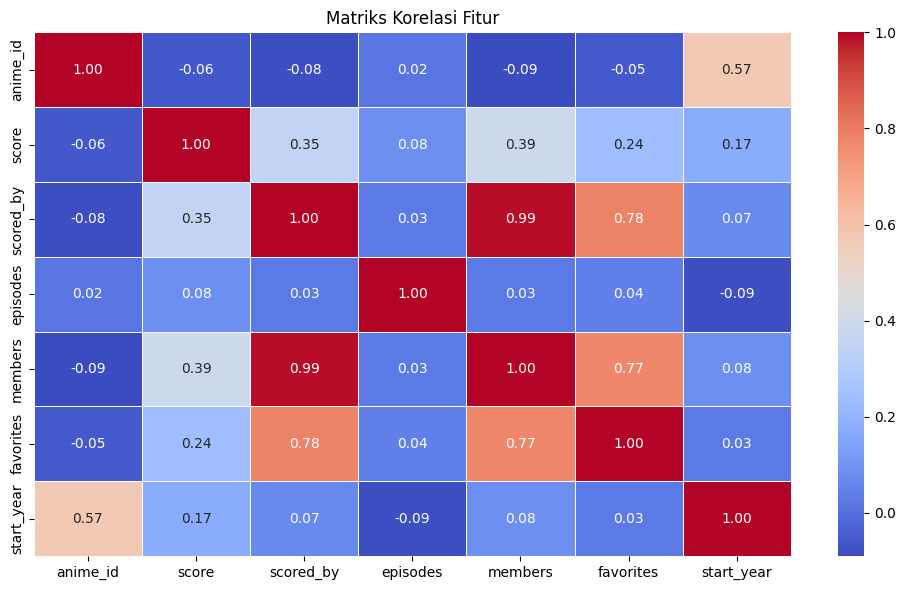

In [227]:
# Menampilkan korelasi matriks
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
correlation = df[numerical_cols].corr()
plt.figure(figsize=(10,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriks Korelasi Fitur")
plt.tight_layout()
plt.show()

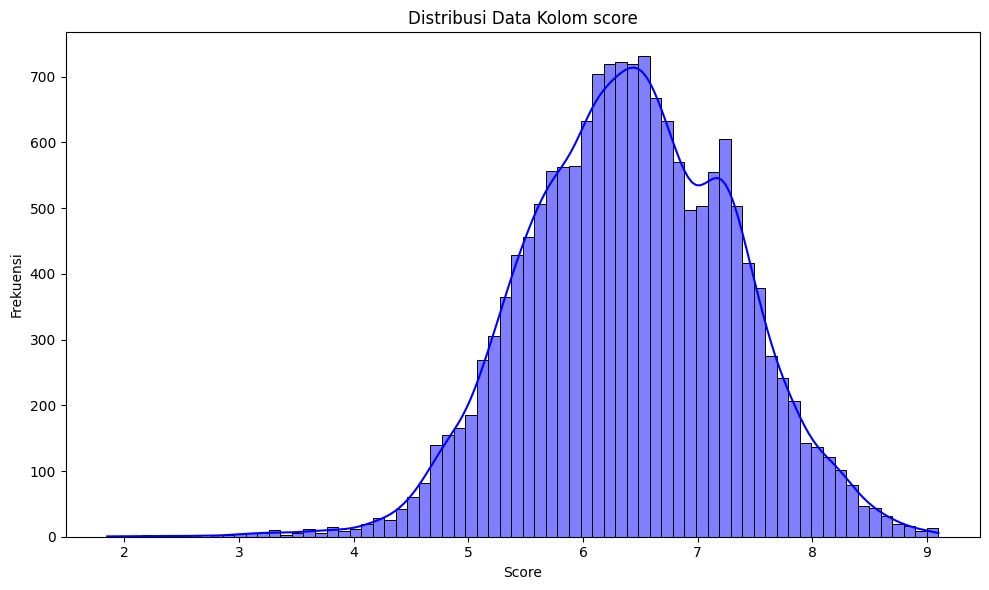

In [226]:
# Menampilkan distribusi data pada kolom score
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="score", kde=True, color="blue")
plt.title("Distribusi Data Kolom score")
plt.xlabel("Score")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

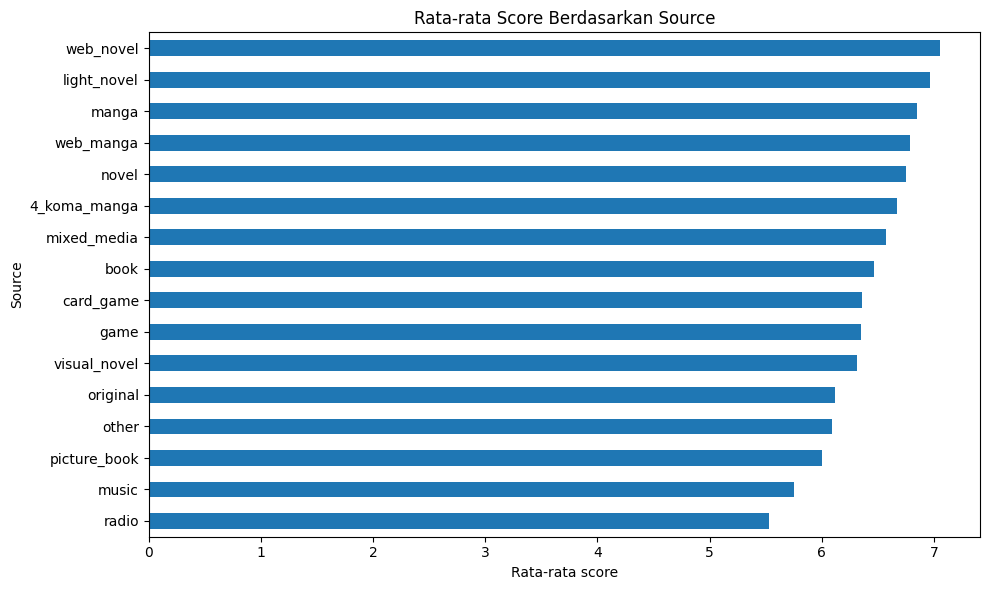

In [225]:
source_mean = df.groupby("source")["score"].mean().sort_values()

plt.figure(figsize=(10,6))
source_mean.plot(kind="barh")

plt.title("Rata-rata Score Berdasarkan Source")
plt.xlabel("Rata-rata score")
plt.ylabel("Source")
plt.tight_layout()
plt.show()

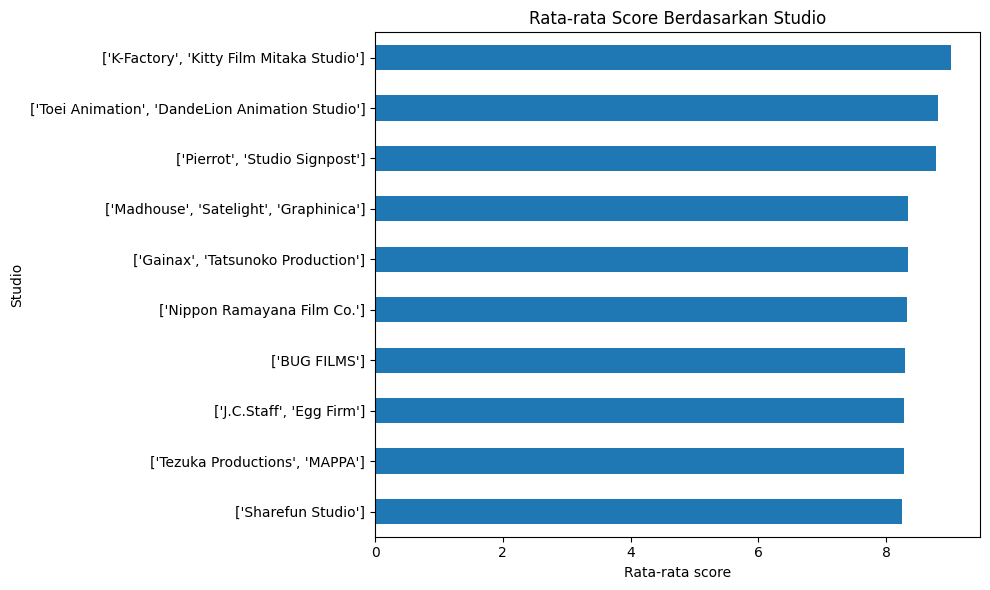

In [224]:
studios_mean = df.groupby("studios")["score"].mean().nlargest(10).sort_values()

plt.figure(figsize=(10,6))
studios_mean.plot(kind="barh")

plt.title("Rata-rata Score Berdasarkan Studio")
plt.xlabel("Rata-rata score")
plt.ylabel("Studio")
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [185]:
# Memilih kolom yang akan dijadikan sebagai fitur
clean_df = df[["genres", "synopsis", "type", "episodes", "producers", "licensors", "studios", "source", "episode_duration", "score", "status"]].copy()
clean_df

,genres,synopsis,type,episodes,producers,licensors,studios,source,episode_duration,score,status
0,"['Action', 'Adventure', 'Drama', 'Fantasy']",After a horrific alchemy experiment goes wrong...,tv,64.0,"['Aniplex', 'Square Enix', 'Mainichi Broadcast...","['Funimation', 'Aniplex of America']",['Bones'],manga,0 days 00:24:20,9.10,finished_airing
1,"['Action', 'Adventure', 'Fantasy']",Hunters devote themselves to accomplishing haz...,tv,148.0,"['VAP', 'Nippon Television Network', 'Shueisha']",['VIZ Media'],['Madhouse'],manga,0 days 00:23:37,9.04,finished_airing
2,"['Action', 'Drama']",Seeking to restore humanity's diminishing hope...,tv,10.0,"['Production I.G', 'Dentsu', 'Mainichi Broadca...",['Funimation'],['Wit Studio'],manga,0 days 00:23:55,9.05,finished_airing
3,"['Drama', 'Sci-Fi', 'Suspense']",Eccentric scientist Rintarou Okabe has a never...,tv,24.0,"['Frontier Works', 'Media Factory', 'Kadokawa ...",['Funimation'],['White Fox'],visual_novel,0 days 00:24:20,9.07,finished_airing
4,"['Award Winning', 'Drama']","As a wild youth, elementary school student Sho...",movie,1.0,"['Shochiku', 'Pony Canyon', 'Kodansha', 'ABC A...","['Eleven Arts', 'NYAV Post']",['Kyoto Animation'],manga,0 days 02:10:03,8.94,finished_airing
...,...,...,...,...,...,...,...,...,...,...,...
24980,['Avant Garde'],"This is an animation using the ""Kaki-mation"" t...",movie,1.0,[],[],[],original,0 days 00:04:08,NaN,finished_airing
24981,[],Music video for the song Kanshajou by Reiko Sa...,music,1.0,['NHK'],[],[],original,0 days 00:02:25,NaN,finished_airing
24982,['Slice of Life'],Follows four dragon-like monsters who came to ...,ona,NaN,[],[],[],web_manga,0 days 00:01:00,NaN,currently_airing
24983,[],Music video for the song Yotsukado no Melody b...,music,1.0,['NHK'],[],['Three-d'],original,0 days 00:02:25,NaN,finished_airing


In [186]:
# Menghapus data yang memiliki nilai NAN
clean_df = clean_df.dropna()

In [187]:
# Membersihkan kolom yang memiliki data dengan nilai [] lalu menggantinya dengan Unknown
kolom_bermasalah = ["producers", "licensors", "studios", "genres"]

for kol in kolom_bermasalah:
    clean_df[kol] = clean_df[kol].replace("[]", "Unknown")

/tmp/ipykernel_4323/1179541837.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df[kol] = clean_df[kol].replace("[]", "Unknown")


In [188]:
def konversi_ke_menit(teks):
    # Mengambil bagian jam:menit:detik di paling akhir teks (contoh: "00:24:20")
    waktu_str = str(teks).split()[-1]

    # Memisahkan angka jam, menit, dan detik berdasarkan tanda titik dua (:)
    jam, menit, detik = waktu_str.split(":")

    # Menghitung total keseluruhan menit
    total_menit = (int(jam) * 60) + int(menit)
    return total_menit


# Menerapkan fungsi ke kolom asli dan menyimpannya ke kolom baru duration_minutes
clean_df["duration_minutes"] = clean_df["episode_duration"].apply(
    konversi_ke_menit
)

# Mengubah tipe data kolom baru menjadi integer
clean_df["duration_minutes"] = clean_df["duration_minutes"].astype(int)

/tmp/ipykernel_4323/3953785466.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df["duration_minutes"] = clean_df["episode_duration"].apply(
/tmp/ipykernel_4323/3953785466.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df["duration_minutes"] = clean_df["duration_minutes"].astype(int)


In [189]:
clean_df["genres"] = clean_df["genres"].apply(
    lambda x: (
        ast.literal_eval(x)
            if isinstance(x, str) and x.startswith("[")
            else [x]
    )
)

genres_mlb = MultiLabelBinarizer()
genres_df = pd.DataFrame(
    genres_mlb.fit_transform(clean_df["genres"]), columns=genres_mlb.classes_
)

len(genres_df.columns)

/tmp/ipykernel_4323/609764226.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df["genres"] = clean_df["genres"].apply(


22

In [190]:
clean_df["producers"] = clean_df["producers"].apply(
    lambda x: (
        ast.literal_eval(x)
            if isinstance(x, str) and x.startswith("[")
            else [x]
    )
)

producers_mlb = MultiLabelBinarizer()
producers_df = pd.DataFrame(
    producers_mlb.fit_transform(clean_df["producers"]), columns=producers_mlb.classes_
)

len(producers_df.columns)

/tmp/ipykernel_4323/1259829935.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df["producers"] = clean_df["producers"].apply(


1395

In [191]:
# Mengurangi jumlah kolom producers agar jumlahnya tidak terlalu banyak
total_kemunculan_producers = producers_df.sum()
kolom_producers_lolos = total_kemunculan_producers.nlargest(50).index
producers_df_clean = producers_df[kolom_producers_lolos]

len(producers_df_clean.columns)

50

In [192]:
clean_df["licensors"] = clean_df["licensors"].apply(
    lambda x: (
        ast.literal_eval(x)
            if isinstance(x, str) and x.startswith("[")
            else [x]
    )
)

licensors_mlb = MultiLabelBinarizer()
licensors_df = pd.DataFrame(
    licensors_mlb.fit_transform(clean_df["licensors"]), columns=licensors_mlb.classes_
)

len(licensors_df.columns)

/tmp/ipykernel_4323/488788754.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df["licensors"] = clean_df["licensors"].apply(


84

In [193]:
# Mengurangi jumlah kolom licensors agar jumlahnya tidak terlalu banyak
total_kemunculan_licensors = licensors_df.sum()
kolom_licensors_lolos = total_kemunculan_licensors.nlargest(50).index
licensors_df_clean = licensors_df[kolom_licensors_lolos]

len(licensors_df_clean.columns)

50

In [194]:
clean_df["studios"] = clean_df["studios"].apply(
    lambda x: (
        ast.literal_eval(x)
            if isinstance(x, str) and x.startswith("[")
            else [x]
    )
)

studios_mlb = MultiLabelBinarizer()
studios_df = pd.DataFrame(
    studios_mlb.fit_transform(clean_df["studios"]), columns=studios_mlb.classes_
)

len(studios_df.columns)

/tmp/ipykernel_4323/1684123057.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df["studios"] = clean_df["studios"].apply(


898

In [195]:
# Mengurangi jumlah kolom studios_df agar jumlahnya tidak terlalu banyak
total_kemunculan_studios = studios_df.sum()
kolom_studios_lolos = total_kemunculan_studios.nlargest(50).index
studios_df_clean = studios_df[kolom_studios_lolos]

len(studios_df_clean.columns)

50

In [196]:
clean_df["synopsis"].str.contains(
    "MAL Rewrite",
    case=False,
    na=False
).sum()

patterns = [
    "Written by MAL Rewrite",
    "MAL Rewrite",
    "(Source: MAL News)",
    "(Source: MAL Rewrite)",
    "(Source: AniDB)",
    "(Source: ANN)",
    "(Source: Wikipedia)",
    "(Source: Crunchyroll)",
    "mal rewrite",
    "written mal",
    "rewrite"
]

for p in patterns:
    clean_df["synopsis"] = clean_df["synopsis"].str.replace(
        p,
        "",
        regex=False
    )

/tmp/ipykernel_4323/1298519941.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df["synopsis"] = clean_df["synopsis"].str.replace(


In [203]:
# Menerapkan TF-IDF untuk diterapkan pada kolom synopsis
tfidf = TfidfVectorizer(max_features=2000, stop_words="english", ngram_range=(1,2), max_df=0.8, min_df=5)

# Mengubah teks sinopsis menjadi angka
synopsis_encoded = tfidf.fit_transform(clean_df["synopsis"].fillna(""))

# Mengubahnya menjadi DataFrame baru
synopsis_df = pd.DataFrame(
    synopsis_encoded.toarray(), columns=tfidf.get_feature_names_out()
)

len(synopsis_df.columns)

2000

In [198]:
# Menerapkan one hot encoding pada kolom source dan type
type_source_df = pd.get_dummies(
    clean_df[["type", "source", "status"]], dtype=int
).reset_index(drop=True)

In [204]:
# Reset indeks data utama agar berurutan dari 0 kembali
clean_df = clean_df.reset_index(drop=True)

# Mengambil fitur angka  dari tabel utama
fitur_numerik = clean_df[["episodes", "duration_minutes"]]

# Menggabungkan semua tabel
final_df = pd.concat(
    [
        fitur_numerik,
        clean_df["score"],
        type_source_df,
        studios_df_clean.reset_index(drop=True),
        licensors_df_clean.reset_index(drop=True),
        producers_df_clean.reset_index(drop=True),
        genres_df.reset_index(drop=True),
        synopsis_df.reset_index(drop=True)
    ],
    axis=1,
)

final_df.shape

(13859, 2199)

In [205]:
final_df.to_csv("anime_preprocessing.csv", index=False)